In [75]:
import imageio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.ndimage as ndi
import numpy as np
import pydicom as dcm
import os

from skimage import exposure, filters, morphology, measure, color, img_as_float

# DICOM

In [76]:
directory = "../dataset/Assigment1/ct-scan/dicom_dir/"

dicom_files = [f for f in os.listdir(directory) if f.endswith('.dcm')]

images = []

for file in dicom_files:
    file_path = os.path.join(directory, file)
    ds = dcm.dcmread(file_path)
    images.append(ds.pixel_array) 

print(f"Loaded {len(images)} images.")

Loaded 100 images.


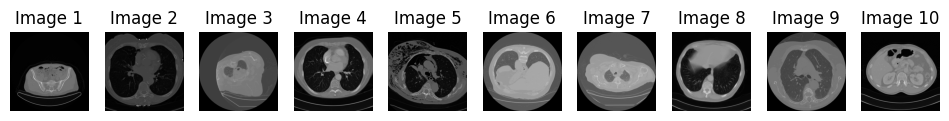

In [77]:
fig, ax = plt.subplots(1, 10, figsize=(12, 6))

# Display only 10 images for visualization
for i in range(10):
    ax[i].imshow(images[i+40], cmap='gray')
    ax[i].set_title(f"Image {i+1}")
    ax[i].axis("off")

plt.show()

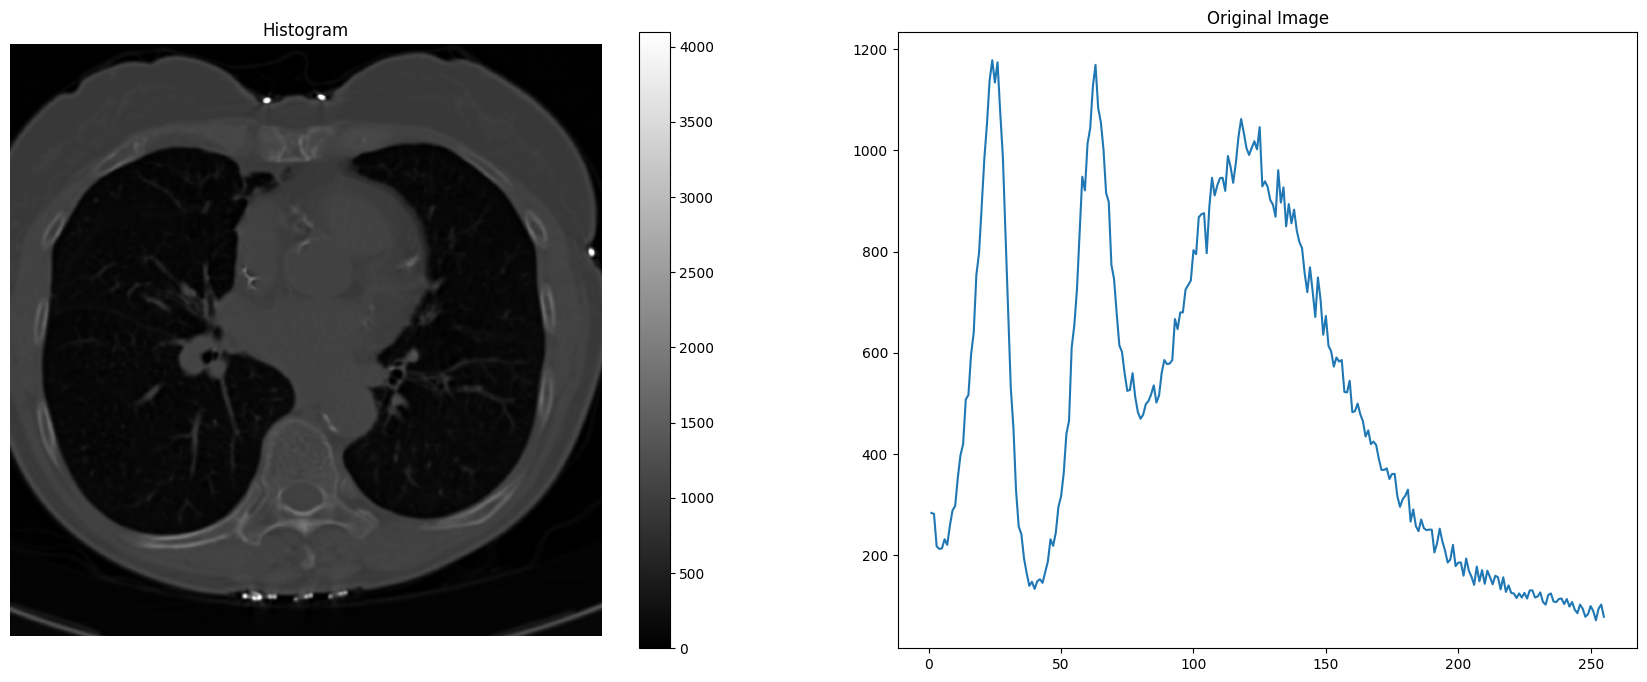

In [83]:
im = images[41] # 4, 17, 18, 25, 30, 34,36, 37, 41, 43 excellent dataset for classic computer vision
hist = ndi.histogram(im, min=0, max=255, bins=256)
x = np.arange(1, len(hist))

fig, ax = plt.subplots(1, 2, figsize=(21, 8))

im_display = ax[0].imshow(im, cmap='gray')
ax[0].set_title('Histogram')
ax[0].axis('off')

ax[1].plot(x, hist[1:])
ax[1].set_title('Original Image')

fig.colorbar(im_display, ax=ax[0])

plt.show()

(-0.5, 511.5, 511.5, -0.5)

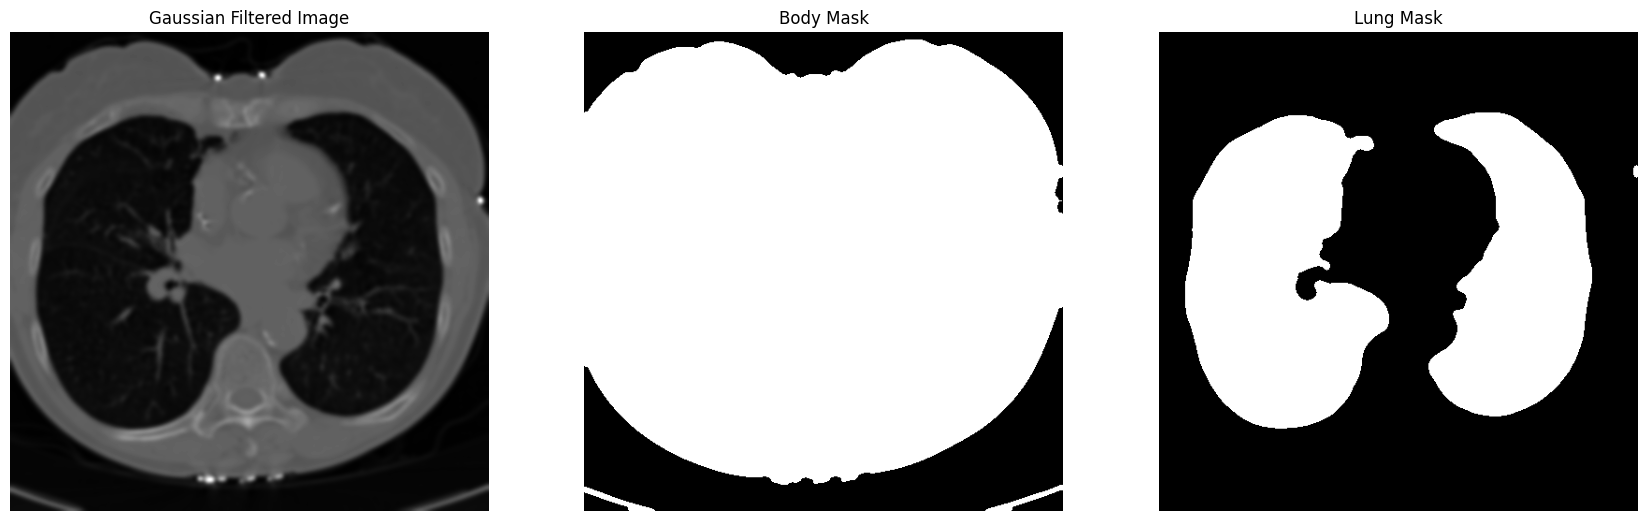

In [84]:
# make body masking
img_filt = ndi.gaussian_filter(im, sigma=2)

th_body = filters.threshold_otsu(img_filt)
body = img_filt > th_body
body = morphology.binary_closing(body, morphology.disk(5))
body = ndi.binary_fill_holes(body)

# get lungs masking
th_lung = filters.threshold_otsu(img_filt)
lung = (img_filt < th_lung) & body
lung = morphology.binary_closing(lung, morphology.disk(5))
lung = ndi.binary_fill_holes(lung)
lung = morphology.binary_opening(lung, morphology.disk(3))

# plt.imshow(img_filt, cmap='gray')

fig, ax = plt.subplots(1, 3, figsize=(21, 8))
ax[0].imshow(img_filt, cmap='gray')
ax[0].set_title('Gaussian Filtered Image')
ax[0].axis('off')
ax[1].imshow(body, cmap='gray')
ax[1].set_title('Body Mask')
ax[1].axis('off')
ax[2].imshow(lung, cmap='gray')
ax[2].set_title('Lung Mask')
ax[2].axis('off')

In [111]:
lung_mask = lung.copy()

labeled = measure.label(lung)
props = sorted(measure.regionprops(labeled), key=lambda r: r.area, reverse=True)

lung_props = sorted(props[:2], key=lambda r: r.centroid[1])   # sort left→right
L, R = lung_props[0].bbox, lung_props[1].bbox

roi_r0 = max(L[0], R[0])                    # top    of overlap zone
roi_r1 = min(L[2], R[2])                    # bottom of overlap zone
roi_c0 = L[3]                               # right edge of left lung
roi_c1 = R[1]                               # left  edge of right lung

# Expand ROI — heart spills a bit beyond the lung gap
h_pad  = int((roi_c1 - roi_c0)* 0.7)
v_pad  = int((roi_r1 - roi_r0) * 0.01) 
roi_r0 = max(0,          roi_r0 - v_pad) 
roi_r1 = min(im.shape[0], roi_r1 + v_pad) - 100 
roi_c0 = max(0,          roi_c0 - h_pad) - 50
roi_c1 = min(im.shape[1], roi_c1 + h_pad) + 50

roi = im[roi_r0:roi_r1, roi_c0:roi_c1]

th_roi    = filters.threshold_otsu(roi)
heart_bin = roi > th_roi

hl        = measure.label(heart_bin)
hr        = sorted(measure.regionprops(hl), key=lambda r: r.area, reverse=True)
heart_roi = hl == hr[0].label

heart_full = np.zeros(im.shape, dtype=bool)
heart_full[roi_r0:roi_r1, roi_c0:roi_c1] = heart_roi

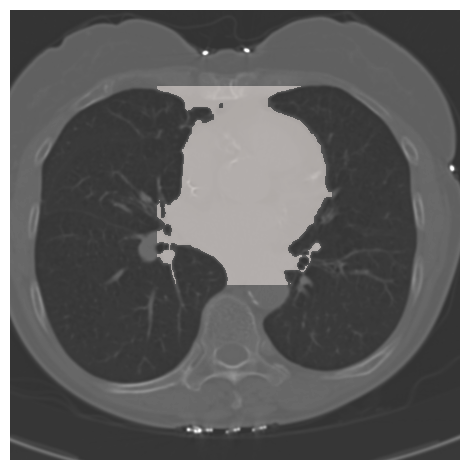

In [ ]:
plt.imshow(im, cmap="gray", alpha=0.8)
plt.imshow(np.ma.masked_where(~heart_full, heart_full), cmap='Reds', alpha=0.5)
plt.axis('off')

plt.tight_layout()
plt.show()


# TIFF 

In [56]:
directory = "../dataset/Assigment1/ct-scan/tiff_images/"

tif_images = [f for f in os.listdir(directory) if f.endswith('.tif')]

images = []

for file in tif_images:
    file_path = os.path.join(directory, file)
    images.append(imageio.imread(file_path))
    
print(f"Loaded {len(images)} images.")

Loaded 100 images.


/tmp/ipykernel_15712/2153200848.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file_path))


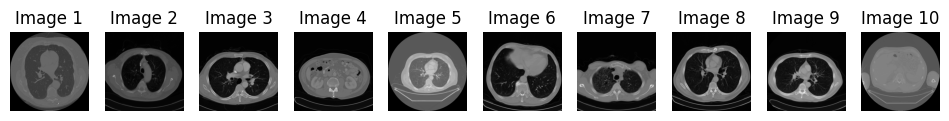

In [57]:
fig, ax = plt.subplots(1, 10, figsize=(12, 6))

# Display only 10 images for visualization
for i in range(10):
    ax[i].imshow(images[i+10], cmap='gray')
    ax[i].set_title(f"Image {i+1}")
    ax[i].axis("off")

plt.show()